# Regularisation in neural networks

### Five ways to stop a network memorising its training set

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com) ·
[all notebooks](../../CURRICULUM.md)

---

| | |
|---|---|
| **What you will learn** | How to make a network overfit on purpose, what dropout, batch norm, weight decay, early stopping and data augmentation each do mechanically, how much of the lost accuracy each one recovers on the same architecture, and why forgetting `model.eval()` quietly ruins your validation numbers |
| **You should already know** | [The PyTorch training loop](../03-the-same-net-in-pytorch/) · [Optimisers](../05-optimisers/) |
| **Dataset** | Fashion-MNIST, cut down to a deliberately small training set |
| **Runtime** | Three to five minutes on a laptop CPU, about one on a GPU |
| **Next** | [07-07 A training loop you can reuse](../07-a-training-loop-you-can-reuse/) · [08-04 Data augmentation](../../08-computer-vision/04-data-augmentation/) |

---

## 1. Overfit on purpose

Regularisation is impossible to judge on a network that is not overfitting.
Every method below costs something (training accuracy, epochs, or both), and if
there is no gap to close, all you measure is the cost.

So I start by building the problem. I take the [PyTorch loop from
07-03](../03-the-same-net-in-pytorch/), point it at Fashion-MNIST, and then throw
away almost all of the data. A couple of thousand images against a couple of
hundred thousand parameters is a network with enough room to store the training
set outright, and that is exactly what it will do.

Small data also keeps this notebook honest about time. Six configurations, same
architecture, same optimiser, same budget, all of it on a laptop.

In [1]:
import sys
import pathlib
import copy
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "toolkit").is_dir())
sys.path.insert(0, str(ROOT))

from toolkit import datasets, style

style.use()
FIG = pathlib.Path("figures")
SEED = 0
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"torch {torch.__version__} on {device}")

torch 2.11.0+cu128 on cuda


In [2]:
from torch.utils.data import Subset, TensorDataset, DataLoader

N_TRAIN = 2000      # small enough that a 200k-parameter network can memorise it
N_VAL = 500         # held out from the training pool, used for early stopping
EPOCHS = 25

train_pool = datasets.fashion_mnist(train=True)
test_set = datasets.fashion_mnist(train=False)
CLASSES = ["T-shirt", "trouser", "pullover", "dress", "coat",
           "sandal", "shirt", "sneaker", "bag", "boot"]

generator = torch.Generator().manual_seed(SEED)
shuffled = torch.randperm(len(train_pool), generator=generator).tolist()
small_train = Subset(train_pool, shuffled[:N_TRAIN])
small_val = Subset(train_pool, shuffled[N_TRAIN:N_TRAIN + N_VAL])


def stack(dataset):
    """Pull a whole dataset into two tensors on the device.

    At these sizes the data fits in memory many times over, and taking the
    DataLoader out of the evaluation path means every configuration below is
    measured the same way.
    """
    images, labels = next(iter(DataLoader(dataset, batch_size=len(dataset))))
    return images.to(device), labels.to(device)


X_train, y_train = stack(small_train)
X_val, y_val = stack(small_val)
X_test, y_test = stack(test_set)

counts = torch.bincount(y_train.cpu(), minlength=10)
print(f"training   : {len(X_train):,} images")
print(f"validation : {len(X_val):,} images (held out of the training pool)")
print(f"test       : {len(X_test):,} images (untouched until the final table)")
print(f"class counts in the training subset: {counts.min().item()} to {counts.max().item()} per class")

training   : 2,000 images
validation : 500 images (held out of the training pool)
test       : 10,000 images (untouched until the final table)
class counts in the training subset: 165 to 219 per class


The test set is the full 10,000 images. Only the training set is small, which is
the situation I want: a real evaluation of a network trained on too little.

One architecture carries the whole notebook. Two hidden layers, ReLU, and two
optional switches, a dropout probability and a batch norm flag, so that every
comparison later is the same network with one thing changed.

In [3]:
def build_net(dropout=0.0, batch_norm=False, widths=(256, 128), n_classes=10):
    """The one architecture, with switches for the two structural regularisers."""
    layers, n_in = [nn.Flatten()], 28 * 28
    for width in widths:
        # Batch norm has its own shift term, so the Linear bias underneath it is
        # redundant. Leaving it in is harmless but it never learns anything.
        layers.append(nn.Linear(n_in, width, bias=not batch_norm))
        if batch_norm:
            layers.append(nn.BatchNorm1d(width))
        layers.append(nn.ReLU())
        if dropout:
            layers.append(nn.Dropout(dropout))
        n_in = width
    layers.append(nn.Linear(n_in, n_classes))
    return nn.Sequential(*layers)


count = lambda m: sum(p.numel() for p in m.parameters())
print(build_net())
print(f"\nparameters : {count(build_net()):,}")
print(f"training images : {N_TRAIN:,}")
print(f"parameters per training image : {count(build_net()) / N_TRAIN:.0f}")

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=256, bias=True)
  (2): ReLU()
  (3): Linear(in_features=256, out_features=128, bias=True)
  (4): ReLU()
  (5): Linear(in_features=128, out_features=10, bias=True)
)

parameters : 235,146
training images : 2,000
parameters per training image : 118


That ratio is the whole setup. The network has far more free parameters than it
has examples to constrain them, so nothing stops it from finding a weight
configuration that fits these particular images and nothing else.

The training loop is the one from 07-03 with two additions: it records the
training set as well as the held-out sets each epoch, because the gap between
them is the quantity this notebook is about, and it takes an optional
augmentation function.

In [4]:
def shift_and_flip(images, max_shift=2):
    """Random horizontal flip and random shift of up to `max_shift` pixels.

    Written with tensor indexing rather than torchvision transforms so that each
    image in the batch gets its own random shift, and so it runs on the GPU
    alongside everything else.
    """
    n = images.shape[0]
    flip = torch.rand(n, device=images.device) < 0.5
    images = torch.where(flip.view(-1, 1, 1, 1), images.flip(-1), images)

    padded = F.pad(images, (max_shift,) * 4)                    # (n, 1, 32, 32)
    offsets = torch.randint(0, 2 * max_shift + 1, (n, 2), device=images.device)
    window = torch.arange(28, device=images.device)
    rows = (offsets[:, 0:1] + window).unsqueeze(2)              # (n, 28, 1)
    cols = (offsets[:, 1:2] + window).unsqueeze(1)              # (n, 1, 28)
    batch = torch.arange(n, device=images.device).view(-1, 1, 1)
    return padded[batch, 0, rows, cols].unsqueeze(1)


def train(model, epochs=EPOCHS, lr=0.05, weight_decay=0.0, batch_size=64, augment=False):
    """The 07-03 loop, recording training and held-out numbers every epoch."""
    model = model.to(device)
    loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)
    loss_fn = nn.CrossEntropyLoss()
    # weight_decay here is L2 on the weights, applied by SGD as an extra -lr*wd*w
    # on every step. Nothing else about the optimiser changes between runs.
    optimiser = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9,
                                weight_decay=weight_decay)

    history = {k: [] for k in ["train_loss", "train_acc", "val_loss", "val_acc", "test_acc"]}
    for _ in range(epochs):
        model.train()                       # dropout on, batch norm on batch statistics
        for xb, yb in loader:
            if augment:
                xb = shift_and_flip(xb)
            optimiser.zero_grad()
            loss_fn(model(xb), yb).backward()
            optimiser.step()

        model.eval()                        # dropout off, batch norm on running statistics
        with torch.no_grad():
            train_logits = model(X_train)
            val_logits = model(X_val)
            history["train_loss"].append(loss_fn(train_logits, y_train).item())
            history["train_acc"].append((train_logits.argmax(1) == y_train).float().mean().item())
            history["val_loss"].append(loss_fn(val_logits, y_val).item())
            history["val_acc"].append((val_logits.argmax(1) == y_val).float().mean().item())
            history["test_acc"].append(
                (model(X_test).argmax(1) == y_test).float().mean().item())
    return model, history


torch.manual_seed(SEED)
baseline_model, baseline = train(build_net())

print(f"training accuracy after {EPOCHS} epochs : {baseline['train_acc'][-1]:.4f}")
print(f"test accuracy after {EPOCHS} epochs     : {baseline['test_acc'][-1]:.4f}")
print(f"gap                                     : "
      f"{baseline['train_acc'][-1] - baseline['test_acc'][-1]:.4f}")
print(f"best test accuracy seen at any epoch    : {max(baseline['test_acc']):.4f} "
      f"(epoch {int(np.argmax(baseline['test_acc'])) + 1})")

training accuracy after 25 epochs : 0.9180
test accuracy after 25 epochs     : 0.8087
gap                                     : 0.1093
best test accuracy seen at any epoch    : 0.8170 (epoch 18)


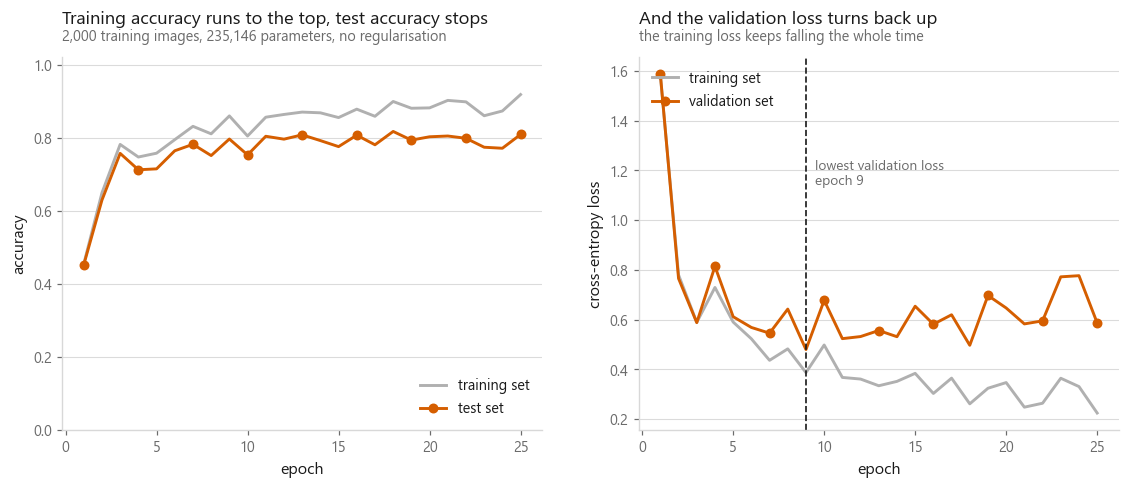

In [5]:
epochs_axis = range(1, EPOCHS + 1)
best_epoch = int(np.argmin(baseline["val_loss"])) + 1

fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.4))

axes[0].plot(epochs_axis, baseline["train_acc"], color=style.NEUTRAL, label="training set")
axes[0].plot(epochs_axis, baseline["test_acc"], color=style.HIGHLIGHT,
             marker=style.MARKERS[0], markevery=3, label="test set")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("accuracy")
axes[0].set_ylim(0, 1.02)
axes[0].legend(loc="lower right")
style.title(axes[0], "Training accuracy runs to the top, test accuracy stops",
            f"{N_TRAIN:,} training images, {count(build_net()):,} parameters, no regularisation")

axes[1].plot(epochs_axis, baseline["train_loss"], color=style.NEUTRAL, label="training set")
axes[1].plot(epochs_axis, baseline["val_loss"], color=style.HIGHLIGHT,
             marker=style.MARKERS[0], markevery=3, label="validation set")
axes[1].axvline(best_epoch, color=style.INK, linestyle="--", linewidth=1.1)
axes[1].annotate(f"lowest validation loss\nepoch {best_epoch}",
                 xy=(best_epoch, max(baseline["val_loss"]) * 0.72),
                 xytext=(6, 0), textcoords="offset points",
                 fontsize=9, color=style.MUTED)
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("cross-entropy loss")
axes[1].legend(loc="upper left")
style.title(axes[1], "And the validation loss turns back up",
            "the training loss keeps falling the whole time")

style.save(fig, FIG / "fig-01-overfitting.png")

Both panels say the same thing in different units. The left one is the version
everybody recognises: the training curve climbs towards perfect while the test
curve flattens out well below it. The right one is more useful, because it shows
the moment things go wrong rather than the end state. The training loss falls
monotonically (it will keep falling if I let it) while the validation loss
bottoms out and then climbs.

After that turning point the network is still learning. It is learning things
that are true of these 2,000 images and false of clothing in general.

## 2. What each regulariser does

All five methods attack the same problem and none of them changes the
architecture. What changes is how freely the optimiser is allowed to use it.

**Dropout.** During training, each unit's activation is set to zero with
probability $p$, chosen fresh on every forward pass. The survivors are scaled up
by $1/(1-p)$ so the expected sum stays the same:

$$m_i \sim \mathrm{Bernoulli}(1-p), \qquad y = \frac{m \odot x}{1-p}$$

The noise is a means to an end, and the end is what it forbids. If unit 40 might
vanish on any given step, no other unit can build a feature that depends on unit
40 being there. Co-adapted groups of units, the kind that memorise a specific
training image between them, stop being viable, and the network is pushed
towards features that stand on their own.

At test time nothing is dropped. The scaling was already applied during training,
which is why this version is called inverted dropout, and it is what
`nn.Dropout` implements.

In [6]:
drop = nn.Dropout(p=0.5)
ones = torch.ones(2, 8)

drop.train()
print("train mode — half zeroed, the rest scaled by 1/(1-p):")
print(drop(ones))

drop.eval()
print("\neval mode — the layer is the identity function:")
print(drop(ones))

train mode — half zeroed, the rest scaled by 1/(1-p):
tensor([[2., 2., 0., 2., 0., 0., 2., 0.],
        [0., 0., 2., 2., 2., 0., 2., 0.]])

eval mode — the layer is the identity function:
tensor([[1., 1., 1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1., 1., 1.]])


**Batch normalisation.** For each feature, subtract the mean and divide by the
standard deviation *of the current mini-batch*, then apply a learned scale and
shift:

$$\hat{x} = \frac{x - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}, \qquad y = \gamma \hat{x} + \beta$$

Batch norm was introduced to make deep networks trainable, and that is still its
main job: it keeps activations in a sane range layer after layer, which lets you
use a larger learning rate without the whole thing diverging. The regularising
effect is partly a side effect. Because $\mu_B$ and $\sigma_B$ come from whichever
examples happen to share the batch, the representation of any single image
wobbles from step to step. That is noise, and noise during training acts like a
mild regulariser, in the same family as dropout but weaker and not adjustable.

At test time there is no batch to normalise against, so the layer switches to
running averages of the statistics collected during training. Those running
averages are stored in the module, not in the gradients, which is the source of
the trap in section 5.

In [7]:
norm = nn.BatchNorm1d(4)
batch = torch.randn(64, 4) * 3 + 5           # mean around 5, standard deviation around 3

norm.train()
normalised = norm(batch)
print(f"input    mean {batch.mean():+.3f}   std {batch.std():.3f}")
print(f"output   mean {normalised.mean():+.3f}   std {normalised.std():.3f}   (batch statistics)")
print(f"\nrunning mean the layer has memorised so far : {norm.running_mean.detach().numpy().round(3)}")
print("those running numbers, not the batch, are what eval mode uses")

input    mean +4.989   std 2.946
output   mean +0.000   std 1.002   (batch statistics)

running mean the layer has memorised so far : [0.473 0.486 0.532 0.504]
those running numbers, not the batch, are what eval mode uses


**Weight decay** is L2 on the weights, and it is the one method here that comes
straight out of the loss function. Add a penalty on the size of the weights:

$$\tilde{\mathcal{L}}(w) = \mathcal{L}(w) + \frac{\lambda}{2}\lVert w \rVert^2$$

Differentiate and the penalty contributes $\lambda w$ to the gradient, so a
gradient descent step becomes

$$w \leftarrow (1 - \eta\lambda)\, w - \eta \nabla \mathcal{L}(w)$$

Every step shrinks the weights a little before the gradient gets its say, which
is where the name comes from. Large weights mean a function with steep responses
to small input changes, which is what memorising individual examples requires;
making them expensive biases the search towards smoother functions.

In PyTorch this is the `weight_decay` argument on the optimiser. With plain SGD
it is exactly the L2 term above. With Adam it is not: the decay gets divided by
the same running gradient scale as everything else, which is why `AdamW` exists
and why you should reach for `AdamW` rather than `Adam(weight_decay=...)`. This
notebook uses SGD with momentum throughout, so the equation and the code agree.

One simplification below: the decay is applied to every parameter, including
biases and batch norm's scale and shift. Production code usually puts those in a
separate parameter group with no decay, since shrinking a shift term towards zero
is not the constraint anyone meant to impose.

**Early stopping** is the free one. The validation loss has a minimum, as the
right panel of figure 1 shows; stop there and keep those weights. It costs no
extra computation, needs no hyperparameter beyond a patience value, and works
alongside everything else. It is also the one people forget, because it does not
feel like a technique.

**Data augmentation** attacks the problem from the other end. Rather than
restricting the network, it manufactures more data by applying label-preserving
transformations: a shift of two pixels, a horizontal flip. A sneaker moved two
pixels right is still a sneaker, so the label survives, but to a network with no
built-in notion of position it is a new example. The network cannot memorise the
training set because it never sees the same training set twice.

augmentation is applied to the training batches only, never to validation or test


Text(0.5, 1.06, 'The same eight garments, shifted and flipped — same labels, new pixels')

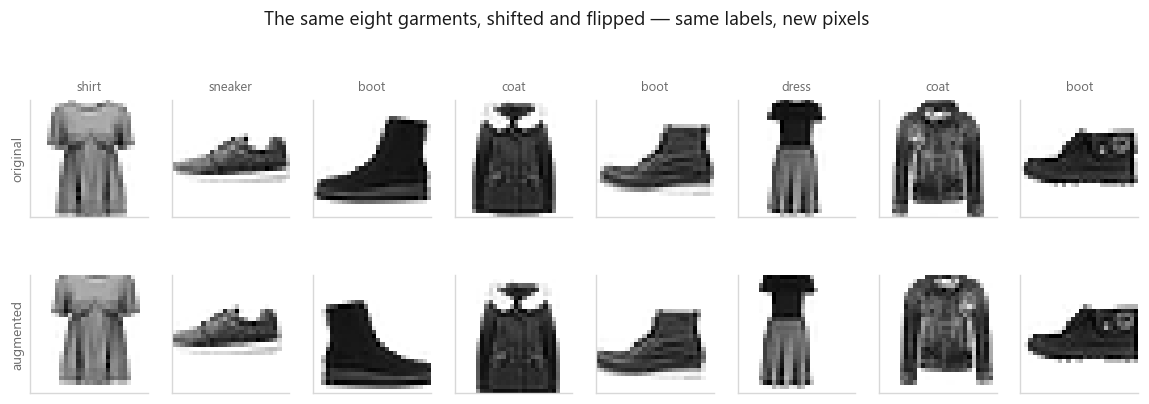

In [8]:
print("augmentation is applied to the training batches only, never to validation or test")

torch.manual_seed(SEED)
sample = X_train[:8].cpu()
augmented = shift_and_flip(X_train[:8]).cpu()

fig, axes = plt.subplots(2, 8, figsize=(13.0, 3.8))
for i in range(8):
    axes[0, i].imshow(sample[i].squeeze(), cmap="gray_r")
    axes[1, i].imshow(augmented[i].squeeze(), cmap="gray_r")
    axes[0, i].set_title(CLASSES[y_train[i].item()], fontsize=8.5, color=style.MUTED)
    for row in (0, 1):
        axes[row, i].set_xticks([]); axes[row, i].set_yticks([]); axes[row, i].grid(False)
axes[0, 0].set_ylabel("original", fontsize=9, color=style.MUTED)
axes[1, 0].set_ylabel("augmented", fontsize=9, color=style.MUTED)
fig.suptitle("The same eight garments, shifted and flipped — same labels, new pixels",
             x=0.5, y=1.06, fontsize=12.5, color=style.INK)

## 3. One at a time, measured

Same architecture, same optimiser, same learning rate, same number of epochs.
One regulariser per run, so whatever moves is attributable.

The values are chosen for a short run on a tiny training set, and they are not
universal. Dropout at 0.3 rather than the classic 0.5, because heavier dropout
needs more epochs to converge than I am giving it here. Weight decay at 1e-2
rather than the 5e-4 you see in papers, because 1e-2 over eight hundred steps
barely shrinks anything.

In [9]:
CONFIGS = [
    ("dropout",      {"dropout": 0.3},     {}),
    ("batch norm",   {"batch_norm": True}, {}),
    ("weight decay", {},                   {"weight_decay": 1e-2}),
    ("augmentation", {},                   {"augment": True}),
]

runs = {"no regularisation": baseline}
models = {"no regularisation": baseline_model}

for label, model_options, train_options in CONFIGS:
    torch.manual_seed(SEED)                 # same initial weights for every run
    started = time.perf_counter()
    model, history = train(build_net(**model_options), **train_options)
    runs[label], models[label] = history, model
    print(f"{label:<14} train {history['train_acc'][-1]:.4f}   "
          f"test {history['test_acc'][-1]:.4f}   "
          f"gap {history['train_acc'][-1] - history['test_acc'][-1]:+.4f}   "
          f"({time.perf_counter() - started:.0f}s)")

dropout        train 0.8665   test 0.7999   gap +0.0666   (7s)


batch norm     train 0.9825   test 0.7932   gap +0.1893   (7s)


weight decay   train 0.7780   test 0.7321   gap +0.0459   (2s)


augmentation   train 0.7910   test 0.7698   gap +0.0212   (4s)


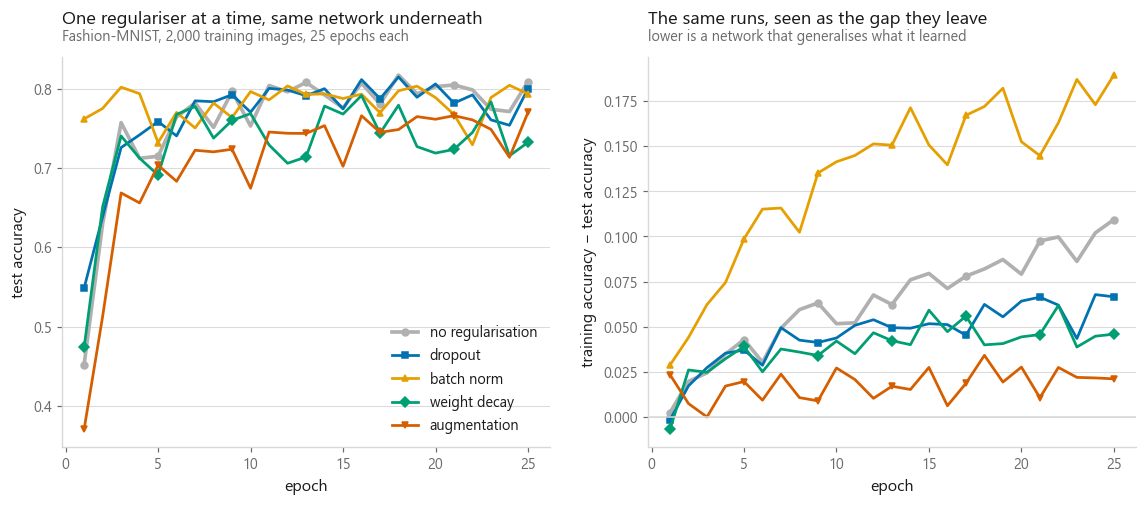

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.6))
order = list(runs)

for i, label in enumerate(order):
    colour = style.NEUTRAL if label == "no regularisation" else style.PALETTE[i - 1]
    width = 2.4 if label == "no regularisation" else 1.8
    axes[0].plot(epochs_axis, runs[label]["test_acc"], color=colour, linewidth=width,
                 marker=style.MARKERS[i], markevery=4, markersize=4.5, label=label)
    gap = np.array(runs[label]["train_acc"]) - np.array(runs[label]["test_acc"])
    axes[1].plot(epochs_axis, gap, color=colour, linewidth=width,
                 marker=style.MARKERS[i], markevery=4, markersize=4.5, label=label)

axes[0].set_xlabel("epoch"); axes[0].set_ylabel("test accuracy")
axes[0].legend(loc="lower right", ncol=1)
style.title(axes[0], "One regulariser at a time, same network underneath",
            f"Fashion-MNIST, {N_TRAIN:,} training images, {EPOCHS} epochs each")

axes[1].set_xlabel("epoch"); axes[1].set_ylabel("training accuracy − test accuracy")
axes[1].axhline(0, color=style.RULE, linewidth=1)
style.title(axes[1], "The same runs, seen as the gap they leave",
            "lower is a network that generalises what it learned")

style.save(fig, FIG / "fig-02-one-at-a-time.png")

Two different questions live in those two panels, and they do not always have the
same answer. A method can close the gap by making the network worse at training,
which is not worth anything on its own. What matters is the left panel: test
accuracy, at the end, on data nothing was tuned against.

### Early stopping, for free

I do not need to train anything to measure early stopping. The baseline run
already recorded the validation loss at every epoch, so I can read off the epoch
it would have stopped at and the test accuracy the network had at that moment.
In practice you would keep a copy of the best weights and a patience counter
instead of the whole curve; the answer is the same.

In [11]:
stop_epoch = int(np.argmin(baseline["val_loss"])) + 1
stopped_test = baseline["test_acc"][stop_epoch - 1]

print(f"validation loss bottomed out at epoch {stop_epoch} of {EPOCHS}")
print(f"test accuracy at that epoch : {stopped_test:.4f}")
print(f"test accuracy at epoch {EPOCHS}   : {baseline['test_acc'][-1]:.4f}")
print(f"difference                  : {stopped_test - baseline['test_acc'][-1]:+.4f}")
print(f"\ntraining epochs saved: {EPOCHS - stop_epoch} "
      f"({(EPOCHS - stop_epoch) / EPOCHS:.0%} of the run)")

runs["early stopping"] = {**baseline, "test_acc": baseline["test_acc"][:stop_epoch]}

validation loss bottomed out at epoch 9 of 25
test accuracy at that epoch : 0.7963
test accuracy at epoch 25   : 0.8087
difference                  : -0.0124

training epochs saved: 16 (64% of the run)


Whatever the size of that difference, it came at negative cost: the epochs after
the stopping point were spent making the model worse. Early stopping is the first
thing to add to a training script and the last thing anyone remembers.

## 4. Combined

The methods are not independent. Dropout and batch norm both inject noise, and
stacking heavy versions of both tends to leave a network that cannot fit anything
in a short run. So the combination uses lighter settings than the individual runs
did: dropout at 0.2 instead of 0.3, weight decay at 5e-3 instead of 1e-2, plus
batch norm, augmentation, and early stopping on top.

In [12]:
torch.manual_seed(SEED)
started = time.perf_counter()
combined_model, combined = train(
    build_net(dropout=0.2, batch_norm=True), weight_decay=5e-3, augment=True)
models["everything"] = combined_model

combined_stop = int(np.argmin(combined["val_loss"])) + 1
print(f"everything : train {combined['train_acc'][-1]:.4f}   "
      f"test {combined['test_acc'][-1]:.4f} after all {EPOCHS} epochs   "
      f"({time.perf_counter() - started:.0f}s)")
print(f"early stopping picks epoch {combined_stop}, "
      f"test accuracy {combined['test_acc'][combined_stop - 1]:.4f}")

# early stopping is part of this configuration, so the row below reports the
# stopped model rather than the one that ran to the end
runs["everything"] = {**combined, "test_acc": combined["test_acc"][:combined_stop]}

everything : train 0.7750   test 0.7533 after all 25 epochs   (4s)
early stopping picks epoch 24, test accuracy 0.7536


In [13]:
summary = pd.DataFrame([
    {"method": label,
     "train acc": history["train_acc"][len(history["test_acc"]) - 1],
     "test acc": history["test_acc"][-1],
     "gap": history["train_acc"][len(history["test_acc"]) - 1] - history["test_acc"][-1],
     "epochs used": len(history["test_acc"]),
     "vs baseline": history["test_acc"][-1] - baseline["test_acc"][-1]}
    for label, history in runs.items()
]).sort_values("test acc").reset_index(drop=True)

print(summary.round(4).to_string(index=False))

           method  train acc  test acc    gap  epochs used  vs baseline
     weight decay     0.7780    0.7321 0.0459           25      -0.0766
       everything     0.7700    0.7536 0.0164           24      -0.0551
     augmentation     0.7910    0.7698 0.0212           25      -0.0389
       batch norm     0.9825    0.7932 0.1893           25      -0.0155
   early stopping     0.8595    0.7963 0.0632            9      -0.0124
          dropout     0.8665    0.7999 0.0666           25      -0.0088
no regularisation     0.9180    0.8087 0.1093           25       0.0000


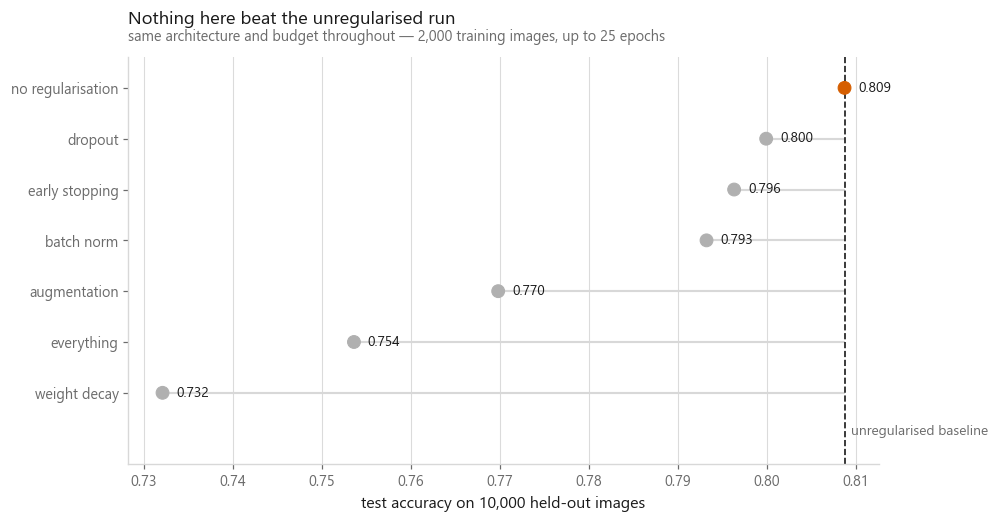

In [14]:
best = summary["method"].iloc[-1]
headline = (f"{best} recovers the most on this network" if best != "no regularisation"
            else "Nothing here beat the unregularised run")
colours = [style.HIGHLIGHT if m == best else style.NEUTRAL for m in summary["method"]]
positions = np.arange(len(summary))

fig, ax = plt.subplots(figsize=(8.8, 4.8))
ax.hlines(positions, baseline["test_acc"][-1], summary["test acc"],
          color=style.RULE, linewidth=1.4, zorder=1)
ax.scatter(summary["test acc"], positions, color=colours, s=70, zorder=3)
ax.axvline(baseline["test_acc"][-1], color=style.INK, linestyle="--", linewidth=1.1, zorder=2)
ax.annotate("unregularised baseline", xy=(baseline["test_acc"][-1], -0.75),
            xytext=(4, 0), textcoords="offset points",
            fontsize=9, color=style.MUTED, va="center")
for y, value in zip(positions, summary["test acc"]):
    ax.annotate(f"{value:.3f}", xy=(value, y), xytext=(9, 0), textcoords="offset points",
                fontsize=9, color=style.INK, va="center")
ax.set_yticks(positions, summary["method"])
ax.set_ylim(-1.4, len(summary) - 0.4)
ax.set_xlabel(f"test accuracy on {len(X_test):,} held-out images")
ax.grid(False, axis="y")
ax.grid(True, axis="x")
style.title(ax, headline,
            f"same architecture and budget throughout — {N_TRAIN:,} training images, "
            f"up to {EPOCHS} epochs")
style.save(fig, FIG / "fig-03-final-accuracy.png")

A dot plot rather than bars, because the interesting range is a few percentage
points wide and starting the axis at zero would compress all of it into nothing.

Read the ordering rather than the individual distances. With one small training
subset and one seed, differences of a fraction of a percent are noise: rerun this
with a different `SEED` and the middle of the table will shuffle. What survives
reseeding is the size of the move away from the unregularised baseline, and which
family of method produced it.

## 5. The train/eval trap

Dropout and batch norm are the only layers so far that behave differently in the
two modes, and both of them do it silently. Nothing raises an exception. Nothing
warns you. The numbers are simply wrong, in a way that looks plausible enough to
put in a report.

There is a second, worse part. A forward pass in training mode also *updates* batch
norm's running statistics. So an evaluation that forgets `model.eval()` reports a
wrong number and edits the model while doing it. That is why the demonstration
below works on a deep copy.

In [15]:
def accuracy(model, X, y, batch_size=500, training_mode=False):
    """Accuracy, evaluated in whichever mode you ask for. Only one of them is right."""
    model.train() if training_mode else model.eval()
    correct = 0
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            correct += (model(X[i:i + batch_size]).argmax(1) == y[i:i + batch_size]).sum().item()
    return correct / len(X)


trap = copy.deepcopy(models["everything"])   # so the demo cannot corrupt the real model

torch.manual_seed(SEED)
correct_accuracy = accuracy(trap, X_test, y_test, training_mode=False)
repeats = [accuracy(trap, X_test, y_test, training_mode=True) for _ in range(15)]

print(f"model.eval()  : {correct_accuracy:.4f}   (the same number every time)")
print(f"model.train() : {np.mean(repeats):.4f} on average, "
      f"ranging {min(repeats):.4f} to {max(repeats):.4f} across 15 identical calls")
print(f"error introduced by forgetting one line : {np.mean(repeats) - correct_accuracy:+.4f}")

model.eval()  : 0.7533   (the same number every time)
model.train() : 0.7351 on average, ranging 0.7327 to 0.7400 across 15 identical calls
error introduced by forgetting one line : -0.0182


train-mode accuracy across batch sizes [8, 16, 32, 64, 128, 500, 2000]:
  0.6426  0.6923  0.7187  0.7257  0.7288  0.7336  0.7321


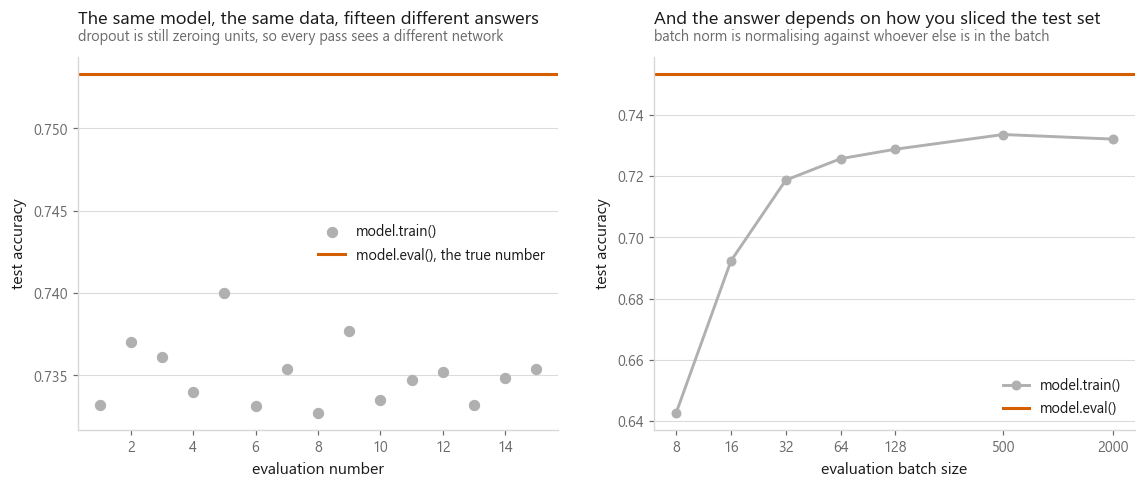

In [16]:
batch_sizes = [8, 16, 32, 64, 128, 500, 2000]
torch.manual_seed(SEED)
# a fresh copy per batch size, since each pass moves the running statistics
by_batch = [accuracy(copy.deepcopy(models["everything"]), X_test, y_test,
                     batch_size=b, training_mode=True) for b in batch_sizes]

fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.4))

axes[0].scatter(range(1, len(repeats) + 1), repeats, color=style.NEUTRAL, s=45,
                label="model.train()")
axes[0].axhline(correct_accuracy, color=style.HIGHLIGHT, linewidth=2,
                label="model.eval(), the true number")
axes[0].set_xlabel("evaluation number")
axes[0].set_ylabel("test accuracy")
axes[0].legend(loc="best")
style.title(axes[0], "The same model, the same data, fifteen different answers",
            "dropout is still zeroing units, so every pass sees a different network")

axes[1].plot(batch_sizes, by_batch, color=style.NEUTRAL, marker=style.MARKERS[0],
             label="model.train()")
axes[1].axhline(correct_accuracy, color=style.HIGHLIGHT, linewidth=2, label="model.eval()")
axes[1].set_xscale("log", base=2)
axes[1].set_xticks(batch_sizes, [str(b) for b in batch_sizes])
axes[1].minorticks_off()
axes[1].set_xlabel("evaluation batch size")
axes[1].set_ylabel("test accuracy")
axes[1].legend(loc="best")
style.title(axes[1], "And the answer depends on how you sliced the test set",
            "batch norm is normalising against whoever else is in the batch")

style.save(fig, FIG / "fig-04-train-eval-trap.png")

print(f"train-mode accuracy across batch sizes {batch_sizes}:")
print("  " + "  ".join(f"{a:.4f}" for a in by_batch))

The right panel is the one that catches people. In training mode the test
accuracy depends on the evaluation batch size, which is a parameter that should
have no effect on anything. It has an effect here because batch norm is
normalising each image against the other images that happen to be in its batch,
so the prediction for one garment depends on which other garments you loaded
beside it.

The failure mode in the wild is quieter than either panel. You leave the model in
training mode during validation, the accuracy comes out a couple of points low,
and you spend an afternoon tuning a learning rate to fix a bug that is one missing
line. Or the reverse: batch norm's running statistics drift during those stray
training-mode forward passes, and a later evaluation is wrong for reasons that no
longer appear anywhere in your code.

Two habits prevent all of it. Put `model.eval()` inside your evaluation function
rather than at the call site, so it cannot be forgotten. Wrap the same function in
`torch.no_grad()` while you are there.

## Cheat sheet

| | |
|---|---|
| **Dropout** | `nn.Dropout(p)` after the activation. Start at 0.5 for wide dense layers, lower for small ones, and rarely in convolutional layers |
| **Batch norm** | `nn.BatchNorm1d/2d` between the linear or conv layer and the activation. Set `bias=False` on the layer underneath it |
| **Weight decay** | `weight_decay` on the optimiser. With SGD it is L2 exactly. With Adam use `AdamW`, never `Adam(weight_decay=...)` |
| **Early stopping** | Track validation loss, keep the best weights, stop after `patience` epochs without improvement. Free |
| **Augmentation** | Training batches only. The transformation has to preserve the label, no vertical flips on digits |
| **Never** | Evaluate without `model.eval()`. It gives wrong numbers and moves batch norm's running statistics |
| **Never** | Tune anything on the test set. Early stopping needs its own validation split |
| **First move** | Get more data, or augment. Every method in this table is a way of coping without it |

## What to remember

1. You cannot judge a regulariser on a network that is not overfitting. Build the
   gap first, then measure what closes it.
2. Dropout zeroes activations at random so that no unit can rely on another being
   present. It is off at test time.
3. Batch norm normalises per mini-batch. Its regularising effect is a side effect
   of that batch noise, and it is not adjustable.
4. Weight decay is L2 on the weights, which appears in the update as a constant
   shrink towards zero on every step.
5. Early stopping costs nothing and everyone forgets it. The epochs after the
   validation minimum are spent making the model worse.
6. Augmentation is the only method here that adds information rather than removing
   freedom, which is why it usually pays best on small data.
7. Combining regularisers is not additive. Their effects overlap, and full-strength
   versions of all of them at once can leave a network that fits nothing.
8. `model.eval()` is not a formality. Forget it and dropout and batch norm hand you
   a wrong number that depends on your batch size.

---

**Made by Elyes Lounissi** ·
[LinkedIn](https://www.linkedin.com/in/elyes-lounissi/) ·
[pilot.tun@gmail.com](mailto:pilot.tun@gmail.com)

Next: [07-07 A training loop you can reuse](../07-a-training-loop-you-can-reuse/) ·
Back to [the curriculum](../../CURRICULUM.md)

`#DeepLearning` `#Regularisation` `#Dropout` `#BatchNorm` `#WeightDecay`
`#PyTorch` `#FashionMNIST` `#MachineLearning` `#Python` `#MLTutorial` `#AI`